### Figure Reconstructions. 

#### Figure 6

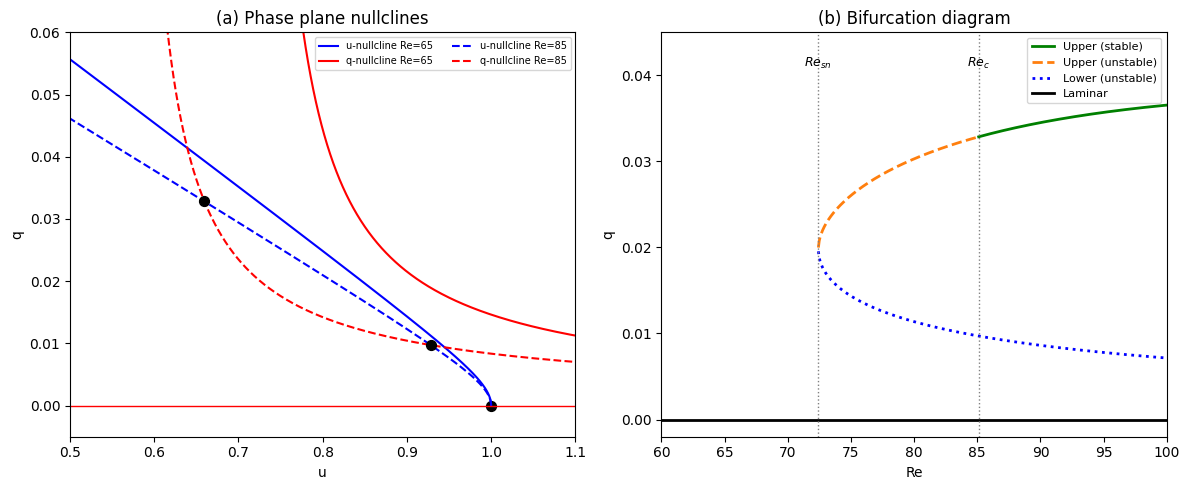

In [3]:
import numpy as np                    # numpy lets us do maths on arrays of numbers
import matplotlib.pyplot as plt       # matplotlib is used to draw the plots
from scipy.optimize import brentq     # brentq finds where a function equals zero

# ── Parameters ────────────────────────────────────────────────────────────────
# These are all the fixed numbers from the paper — they do not change
beta  = np.pi / 2    # β = π/2, the lowest vertical wavenumber set by the geometry
alpha = 0.01         # α, the Ekman drag coefficient for the shear modes
a     = 0.3          # controls the amplitude of the Reynolds stress closure A(q)
eta   = 5e-3         # η = 0.005, controls how A(q) tapers off at tiny turbulence levels
c     = 9.65         # controls the amplitude of turbulent dissipation ε₀

# ── Closures ──────────────────────────────────────────────────────────────────
# These are the turbulence closure functions defined in the paper

def A(q):
    # Reynolds stress amplitude A(q₀) — equation 2.14
    # For large q this is roughly a*q; for tiny q it tapers smoothly to zero
    return a * (np.sqrt(q**2 + eta**2) - eta)

def dA(q):
    # Derivative of A with respect to q — needed when we linearise the equations
    # Computed using standard calculus on the expression above
    return a * q / np.sqrt(q**2 + eta**2)

def eps0(q, Re):
    # Turbulent pseudo-dissipation ε₀ — equation 2.15
    # Grows with turbulence level q and decreases with Reynolds number Re
    return (c / Re) * q

# ── Nullclines ────────────────────────────────────────────────────────────────
# These rearrange the local dynamics equations so we can plot nullclines
# A nullcline is a curve in the phase plane where one variable stops changing

def u_from_u_nullcline(q, Re):
    # The u-nullcline: the value of u where u̇ = 0, written as a function of q
    # Found by setting the right-hand side of equation 3.1a to zero and solving for u
    return 1.0 - beta * A(q) / (alpha + beta**2 / Re)

def u_from_q_nullcline(q, Re):
    # The q-nullcline for q > 0: the value of u where q̇ = 0, as a function of q
    # Found by setting the right-hand side of equation 3.1b to zero and solving for u
    return 2.0 * (2*alpha + c/Re) * q / (beta * A(q))

# ── Right-hand sides ──────────────────────────────────────────────────────────
# These are the actual local ODE right-hand sides from equations 3.1a and 3.1b

def udot(u, q, Re):
    # Rate of change of u — how fast the shear profile amplitude changes over time
    return (alpha + beta**2/Re) * (1 - u) - beta * A(q)

def qdot(u, q, Re):
    # Rate of change of q — how fast the turbulent kinetic energy changes over time
    return 0.5 * beta * u * A(q) - 2*alpha*q - eps0(q, Re)

# ── Jacobian ──────────────────────────────────────────────────────────────────
def jacobian(u, q, Re):
    # The Jacobian is a 2x2 matrix of partial derivatives of the two ODEs
    # Its eigenvalues tell us whether a steady state is stable or unstable

    J11 = -(alpha + beta**2 / Re)               # ∂u̇/∂u — how u̇ changes with u
    J12 = -beta * dA(q)                          # ∂u̇/∂q — how u̇ changes with q
    J21 =  0.5 * beta * A(q)                    # ∂q̇/∂u — how q̇ changes with u
    J22 =  0.5 * beta * u * dA(q) - 2*alpha - c/Re  # ∂q̇/∂q — how q̇ changes with q

    # Pack the four entries into a 2x2 numpy array and return it
    return np.array([[J11, J12], [J21, J22]])

# ── Generic root finder ────────────────────────────────────────────────────────
def find_roots(f, q_scan):
    # Finds all values of q where f(q) = 0 by scanning for sign changes
    # f is the function we want to find roots of
    # q_scan is the array of q values to check

    # Evaluate f at every q value in the scan array
    f_vals = f(q_scan)

    # Empty list to collect any roots we find
    roots = []

    # Check each neighbouring pair of q values for a sign change
    for i in range(len(q_scan) - 1):

        # A sign change means f crossed zero somewhere between these two points
        if f_vals[i] * f_vals[i+1] < 0:

            # Use brentq to find the exact location of the root in this interval
            roots.append(brentq(f, q_scan[i], q_scan[i+1]))

    # Return the complete list of roots found
    return roots

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 6a — Phase plane
# ═══════════════════════════════════════════════════════════════════════════════
# Create a figure with two panels side by side, each 6 inches wide and 5 tall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Point ax at the left panel — this will hold the phase plane plot
ax = axes[0]

# Array of q values to draw the nullclines over; start just above zero to avoid issues
q_plot = np.linspace(1e-5, 0.06, 800)

# Draw the nullclines for two Reynolds numbers: Re=65 (solid) and Re=85 (dashed)
for Re, ls in zip([65, 85], ['-', '--']):

    # Define the mismatch function — zero where both nullclines intersect (steady states)
    mismatch = lambda q: u_from_u_nullcline(q, Re) - u_from_q_nullcline(q, Re)

    # Compute the u-nullcline values and draw them in blue
    u_unc = u_from_u_nullcline(q_plot, Re)
    ax.plot(u_unc, q_plot, color='blue', ls=ls, label=f'u-nullcline Re={Re}')

    # Compute the q-nullcline values and draw them in red
    u_qnc = u_from_q_nullcline(q_plot, Re)
    ax.plot(u_qnc, q_plot, color='red', ls=ls, label=f'q-nullcline Re={Re}')

    # Find where the two nullclines cross — these are the turbulent steady states
    roots_q = find_roots(mismatch, np.linspace(1e-4, 0.06, 2000))

    # For each steady state found, compute its u coordinate and mark it with a dot
    for q_r in roots_q:
        u_r = u_from_u_nullcline(q_r, Re)          # u coordinate of the steady state
        ax.scatter(u_r, q_r, color='black', s=50, zorder=5)   # black dot on top of everything

# Mark the laminar steady state at (u=1, q=0) — it always exists for every Re
ax.scatter(1.0, 0.0, color='black', s=50)

# Draw the q = 0 segment of the q-nullcline as a thin red horizontal line
u_axis = np.linspace(0.5, 1.1, 200)                # span the whole visible u range
ax.plot(u_axis, np.zeros_like(u_axis), color='red', lw=1)

# Set the axis limits to match the paper's figure
ax.set_xlim(0.5, 1.1)
ax.set_ylim(-0.005, 0.06)

# Label the axes and add a title and legend
ax.set_xlabel("u")
ax.set_ylabel("q")
ax.set_title("(a) Phase plane nullclines")
ax.legend(fontsize=7, ncol=2)

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 6b — Bifurcation diagram
# ═══════════════════════════════════════════════════════════════════════════════
# Point ax2 at the right panel — this will hold the bifurcation diagram
ax2 = axes[1]

# Sweep over Reynolds numbers from 60 to 100 using 600 evenly spaced values
Re_vals = np.linspace(60, 100, 600)

# Rec is the critical Reynolds number from the paper below which uniform turbulence
# becomes unstable to spatial patterns (turbulent bands)
Rec  = 85.1

# Re_sn is the saddle-node Reynolds number where turbulent states first appear
Re_sn = 72.4

# Empty lists to store the Re and q values for the upper and lower branches
lower_Re, lower_q = [], []
upper_Re, upper_q = [], []

# Fine array of q values used when scanning for steady states at each Re
q_scan_bif = np.linspace(1e-4, 0.08, 2000)

# Loop over every Re value and find the turbulent steady states
for Re in Re_vals:

    # Mismatch function — zero where both nullclines cross, i.e. at steady states
    mismatch = lambda q: u_from_u_nullcline(q, Re) - u_from_q_nullcline(q, Re)

    # Find all roots of the mismatch function using the generic root finder
    roots_q = find_roots(mismatch, q_scan_bif)

    if len(roots_q) == 2:
        # Two roots found: sort them so q_low is the lower branch, q_high the upper
        q_low, q_high = sorted(roots_q)

        # Store the lower branch point
        lower_Re.append(Re); lower_q.append(q_low)

        # Store the upper branch point
        upper_Re.append(Re); upper_q.append(q_high)

    elif len(roots_q) == 1:
        # Only one root: we are above the saddle-node, only upper branch exists
        upper_Re.append(Re); upper_q.append(roots_q[0])

# Convert the upper branch lists to numpy arrays so we can apply boolean masks
upper_Re = np.array(upper_Re)
upper_q  = np.array(upper_q)

# Create boolean masks to separate the stable and unstable parts of the upper branch
mask_stable   = upper_Re >= Rec    # stable to patterns above Rec — drawn solid
mask_unstable = upper_Re <  Rec    # unstable to patterns below Rec — drawn dashed

# Draw the stable part of the upper branch as a solid green line
ax2.plot(upper_Re[mask_stable],   upper_q[mask_stable],
         'g-',   lw=2, label='Upper (stable)')

# Draw the unstable part of the upper branch as a dashed orange line
ax2.plot(upper_Re[mask_unstable], upper_q[mask_unstable],
         'C1--', lw=2, label='Upper (unstable)')

# Draw the lower branch as a dotted blue line — it is always unstable
ax2.plot(lower_Re, lower_q, 'b:', lw=2, label='Lower (unstable)')

# Draw the laminar branch as a solid black line along q = 0
ax2.plot(Re_vals, np.zeros_like(Re_vals), 'k-', lw=2, label='Laminar')

# Mark the saddle-node Re with a vertical dotted grey line
ax2.axvline(Re_sn, color='grey', ls=':', lw=1)

# Mark the critical Re with another vertical dotted grey line
ax2.axvline(Rec,   color='grey', ls=':', lw=1)

# Add text labels just above each vertical marker line
ax2.text(Re_sn, 0.041, r'$Re_{sn}$', ha='center', fontsize=9)
ax2.text(Rec,   0.041, r'$Re_c$',    ha='center', fontsize=9)

# Set the axis limits to match the paper
ax2.set_xlim(60, 100)
ax2.set_ylim(-0.002, 0.045)

# Label the axes and add a title and legend
ax2.set_xlabel("Re")
ax2.set_ylabel("q")
ax2.set_title("(b) Bifurcation diagram")
ax2.legend(fontsize=8)

# Tighten the spacing between the two panels so they do not overlap
plt.tight_layout()

# Save the completed figure to a file at 150 dots per inch
plt.savefig("figure6_reproduction.png", dpi=150)

# Display the figure on screen
plt.show()

#### Figure 10

Panel (a): Re = 73.0
Re=73.0: uss=0.8036, qss=0.02271
Panel (b): Re = 84.7
Re=84.7: uss=0.6620, qss=0.03269
Panel (c): Re = 84.7 (long-wavelength)
Re=84.7: uss=0.6620, qss=0.03269


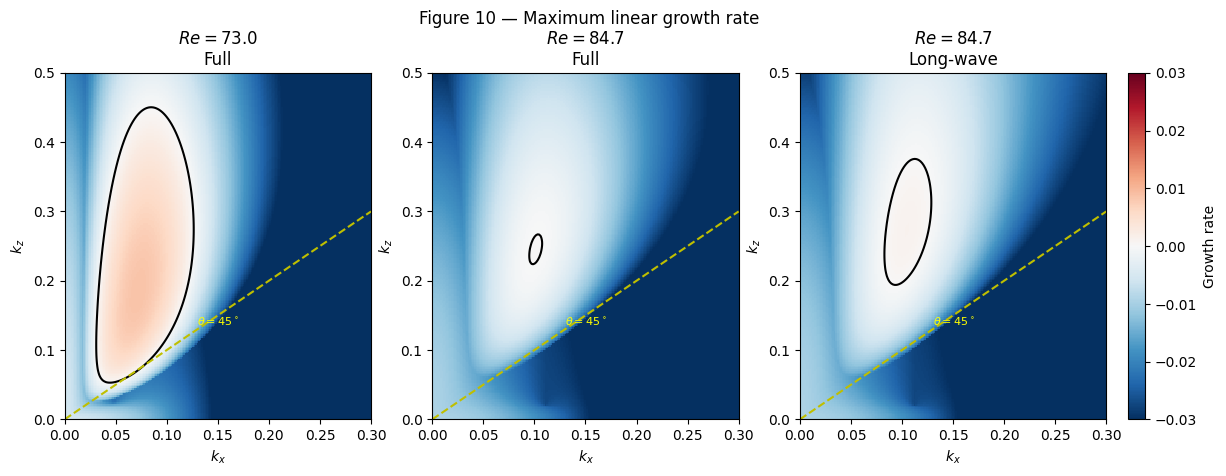

In [5]:
# ── Closures ──────────────────────────────────────────────────────────────────
# These are the turbulence closure functions defined in the paper
def nuT(q, Re):
    # Turbulent diffusivity νT — equation 2.17
    # Describes how turbulence spreads spatially; grows with both q and Re
    return d * Re * q

# ── Generic root finder ────────────────────────────────────────────────────────
def find_roots(f, q_scan):
    # Finds all values of q where f(q) = 0 by scanning for sign changes
    # f is the function to find roots of; q_scan is the array of values to check

    # Evaluate f at every point in the scan array
    fv = f(q_scan)

    # Empty list to collect roots
    roots = []

    # Check each neighbouring pair for a sign change indicating a root
    for i in range(len(q_scan) - 1):

        # A sign change means f crossed zero somewhere in this interval
        if fv[i] * fv[i+1] < 0:

            # Pin down the exact root location using brentq
            roots.append(brentq(f, q_scan[i], q_scan[i+1]))

    # Return the full list of roots found
    return roots

# ── Find upper-branch steady state ────────────────────────────────────────────
def find_upper_branch(Re):
    # Given a Reynolds number, find the (uss, qss) of the upper-branch turbulent state
    # This is the high-turbulence steady state at the top of the S-curve in Figure 6b

    # u-nullcline: value of u where u̇ = 0, as a function of q
    u_unc = lambda q: 1.0 - beta * A(q) / (alpha + beta**2 / Re)

    # q-nullcline: value of u where q̇ = 0, as a function of q (for q > 0)
    u_qnc = lambda q: 2.0 * (2*alpha + c/Re) * q / (beta * A(q))

    # Mismatch function — zero where both nullclines cross, i.e. at steady states
    mismatch = lambda q: u_unc(q) - u_qnc(q)

    # Scan over a fine array of q values to find all steady states
    q_scan = np.linspace(1e-4, 0.08, 3000)

    # Use the generic root finder to locate all roots
    roots = find_roots(mismatch, q_scan)

    # If no roots found, no turbulent state exists at this Re — return None
    if not roots:
        return None, None

    # The upper branch has the largest q value among all roots found
    q_upper = max(roots)

    # Compute the corresponding u value from the u-nullcline
    return u_unc(q_upper), q_upper

# ── Stability matrix ──────────────────────────────────────────────────────────
def build_matrix(kx, kz, Re, uss, qss, lw=False):
    # Builds the 6x6 complex stability matrix M
    # The eigenvalues σ of M tell us how fast small perturbations grow or decay
    # State vector order: (û₀, û₁, v̂₁, ŵ₀, ŵ₁, q̂₀)
    # lw=False uses the full equations B1; lw=True uses the long-wavelength B4

    # k² = kx² + kz², the squared magnitude of the horizontal wave vector
    # The small guard value 1e-20 prevents division by zero at exactly k = 0
    k2  = max(kx**2 + kz**2, 1e-20)

    # k² + β², appears in the full equations due to the 3D Laplacian
    kb2 = k2 + beta**2

    # Evaluate closure functions and their derivatives at the steady state
    Ass  = A(qss)          # Reynolds stress amplitude at the steady state
    Apps = dA(qss)         # its derivative — appears throughout the linearisation
    epsp = c / Re          # derivative of ε₀ with respect to q (ε₀ is linear in q)
    nT   = nuT(qss, Re)    # turbulent diffusivity at the steady state

    # Compute ∂q̇₀/∂q₀ evaluated at the steady state — equation B3
    # Bundles together linearised production, dissipation, diffusion, and advection
    Dq = (0.5*beta*uss*Apps - 2*alpha - epsp       # production minus friction and dissipation
          - k2/Re - nT*k2                           # viscous and turbulent diffusion
          - uss**2 * kx**2 / (2*(2*alpha + kappa + beta**2/Re)))  # advection of q1

    # Initialise a 6x6 matrix of zeros; dtype=complex because eigenvalues can be complex
    M = np.zeros((6, 6), dtype=complex)

    if lw:
        # ── Long-wavelength approximation (equation B4) ────────────────────────
        # Terms of order (k/β)² are dropped as negligible when k ≪ β

        # Row 0: û₀ — streamwise bulk momentum
        M[0,0] = -alpha0                               # Ekman drag on the bulk mode
        M[0,1] = -0.5j * kx * uss                     # advection of û₁ by the base shear
        M[0,2] = beta * uss * (kx**2/k2 - 0.5)        # pressure minus advection from v̂₁

        # Row 1: û₁ — streamwise shear momentum
        M[1,0] = -1j * kx * uss                        # advection of û₀ by the base shear
        M[1,1] = -(alpha + beta**2/Re)                 # Ekman drag plus viscous dissipation
        M[1,5] = -beta * Apps                          # Reynolds stress force from q̂₀

        # Row 2: v̂₁ — wall-normal momentum
        M[2,2] = -(alpha + beta**2/Re)                 # Ekman drag plus viscous dissipation
        M[2,5] = -1j * kx * Apps                      # Reynolds stress force from q̂₀

        # Row 3: ŵ₀ — spanwise bulk momentum
        M[3,2] = beta * uss * kx * kz / k2            # pressure contribution from v̂₁
        M[3,3] = -alpha0                               # Ekman drag on the bulk mode
        M[3,4] = -0.5j * kx * uss                     # advection of ŵ₁ by the base flow

        # Row 4: ŵ₁ — spanwise shear momentum
        M[4,3] = -1j * kx * uss                        # advection of ŵ₀ by the base flow
        M[4,4] = -(alpha + beta**2/Re)                 # Ekman drag plus viscous dissipation

        # Row 5: q̂₀ — turbulent kinetic energy
        M[5,1] = 0.5 * beta * Ass                     # TKE production from û₁
        M[5,5] = Dq                                    # all other linearised TKE terms

        # Return the completed long-wavelength matrix
        return M

    # ── Full system (equation B1) ──────────────────────────────────────────────
    # All terms retained; no long-wavelength simplification applied

    # Row 0: û₀ — streamwise bulk momentum
    M[0,0] = -(k2/Re + alpha0)                        # viscous dissipation plus Ekman drag
    M[0,1] = -0.5j * kx * uss                         # advection coupling to û₁
    M[0,2] = beta * uss * (kx**2/k2 - 0.5)            # pressure minus advection from v̂₁

    # Row 1: û₁ — streamwise shear momentum
    M[1,0] = -1j * kx * uss                            # advection of û₀
    M[1,1] = -(kb2/Re + alpha)                        # full 3D viscous dissipation plus drag
    M[1,2] = -1j * kx * alpha * beta / kb2            # pressure-drag cross term involving v̂₁
    M[1,5] = -(1 - 2*kx**2/kb2) * beta * Apps        # Reynolds stress projected onto this mode

    # Row 2: v̂₁ — wall-normal momentum
    M[2,2] = -(alpha*beta**2/kb2 + kb2/Re)            # projected Ekman drag plus viscous term
    M[2,5] = (1 - 2*beta**2/kb2) * 1j * kx * Apps    # projected Reynolds stress force

    # Row 3: ŵ₀ — spanwise bulk momentum
    M[3,2] = kx*kz*beta*uss/k2                        # pressure coupling from v̂₁
    M[3,3] = -(k2/Re + alpha0)                        # viscous dissipation plus Ekman drag
    M[3,4] = -0.5j * kx * uss                         # advection coupling to ŵ₁

    # Row 4: ŵ₁ — spanwise shear momentum
    M[4,2] = -1j * kz * alpha * beta / kb2            # pressure-drag cross term involving v̂₁
    M[4,3] = -1j * kx * uss                            # advection of ŵ₀
    M[4,4] = -(kb2/Re + alpha)                        # full 3D viscous dissipation plus drag
    M[4,5] = 2*kx*kz*beta*Apps/kb2                    # off-diagonal Reynolds stress projection

    # Row 5: q̂₀ — turbulent kinetic energy
    M[5,1] = 0.5 * beta * Ass                         # TKE production from û₁
    M[5,2] = 0.5 * Ass * 1j * kx                      # TKE production from v̂₁ (full system only)
    M[5,5] = Dq                                        # all other linearised TKE terms

    # Return the completed full matrix
    return M

# ── Growth-rate map ───────────────────────────────────────────────────────────
def compute_growth_map(kx_arr, kz_arr, Re, lw=False):
    # Sweeps over all (kx, kz) pairs and records the maximum growth rate at each point

    # Find the turbulent steady state to linearise around
    uss, qss = find_upper_branch(Re)

    # If no turbulent state exists at this Re, stop and raise an informative error
    if uss is None:
        raise ValueError(f"No upper-branch state at Re={Re}")

    # Print the steady state values so we can check them while the code runs
    print(f"Re={Re}: uss={uss:.4f}, qss={qss:.5f}")

    # Pre-allocate a 2D array to store the maximum growth rate at every (kx, kz) point
    # Rows correspond to kz values, columns to kx values
    growth = np.zeros((len(kz_arr), len(kx_arr)))

    # Outer loop over all spanwise wavenumbers kz (rows of the growth array)
    for j, kz in enumerate(kz_arr):

        # Inner loop over all streamwise wavenumbers kx (columns of the growth array)
        for i, kx in enumerate(kx_arr):

            # Build the 6x6 stability matrix at this particular (kx, kz) pair
            M = build_matrix(kx, kz, Re, uss, qss, lw)

            # Compute all 6 eigenvalues and store the largest real part
            # A positive value means perturbations grow → the state is linearly unstable
            growth[j,i] = np.max(np.real(np.linalg.eigvals(M)))

    # Return the completed 2D array of maximum growth rates
    return growth

# ── Wavenumber grid ───────────────────────────────────────────────────────────
# Define the range of kx and kz values to scan over
# These are slightly wider than the paper to make sure we capture the full picture
nk     = 200                             # number of points in each direction; higher = sharper
kx_arr = np.linspace(0.001, 0.3, nk)    # streamwise wavenumbers from near-zero to 0.3
kz_arr = np.linspace(0.001, 0.5, nk)    # spanwise wavenumbers from near-zero to 0.5

# ── Compute the three panels ──────────────────────────────────────────────────
# Panel (a): full system just above Re_sn — should show no instability (all blue)
print("Panel (a): Re = 73.0")
G_a = compute_growth_map(kx_arr, kz_arr, 73.0, lw=False)

# Panel (b): full system just below Re_c — should show a small unstable region (red blob)
print("Panel (b): Re = 84.7")
G_b = compute_growth_map(kx_arr, kz_arr, 84.7, lw=False)

# Panel (c): long-wavelength approximation at the same Re — should look similar to (b)
print("Panel (c): Re = 84.7 (long-wavelength)")
G_c = compute_growth_map(kx_arr, kz_arr, 84.7, lw=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
# Create a figure with three side-by-side panels
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Build a 2D meshgrid so pcolormesh knows where to place each colour cell
KX, KZ = np.meshgrid(kx_arr, kz_arr)

# Set colour scale symmetrically around zero: blue = stable, red = unstable
vmin, vmax = -0.03, 0.03

# Bundle together the three data arrays with their panel titles
panels = [
    (G_a, r'$Re=73.0$'  + '\nFull'),           # panel (a) data and title
    (G_b, r'$Re=84.7$'  + '\nFull'),           # panel (b) data and title
    (G_c, r'$Re=84.7$'  + '\nLong-wave'),      # panel (c) data and title
]

# Draw each of the three panels
for ax, (G, title) in zip(axes, panels):

    # Draw the filled colour map; RdBu_r makes negative values blue and positive red
    im = ax.pcolormesh(KX, KZ, G, cmap='RdBu_r',
                       vmin=vmin, vmax=vmax, shading='auto')

    # Draw the neutral stability curve where growth rate = 0
    ax.contour(KX, KZ, G, levels=[0], colors='black', linewidths=1.5)

    # Draw the θ = 45° reference line: tan θ = kx/kz = 1 means kx = kz
    diag = np.linspace(0, 0.3, 200)               # x-coordinates of the diagonal
    ax.plot(diag, diag, 'y--', lw=1.5)            # dashed yellow diagonal line
    ax.text(0.13, 0.135, r'$\theta=45^\circ$',    # label placed near the line
            color='yellow', fontsize=8)

    # Set axis limits to match the wider wavenumber range used here
    ax.set_xlim(0, 0.3)
    ax.set_ylim(0, 0.5)

    # Label the axes with the correct mathematical symbols
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_z$')

    # Add the panel title
    ax.set_title(title)

# Add a single shared colourbar on the right of all three panels
cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('Growth rate')      # label the colourbar axis

# Add an overall title above all three panels
plt.suptitle('Figure 10 — Maximum linear growth rate', fontsize=12, y=1.02)

# Save the figure to a file and display it on screen
plt.savefig('figure10_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()